In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Plot styling: To make the charts look professional
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Load the clean data
df = pd.read_csv('../data/processed/cleaned_data.csv')
print("Shape:", df.shape)
df.head()


Shape: (101766, 43)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0


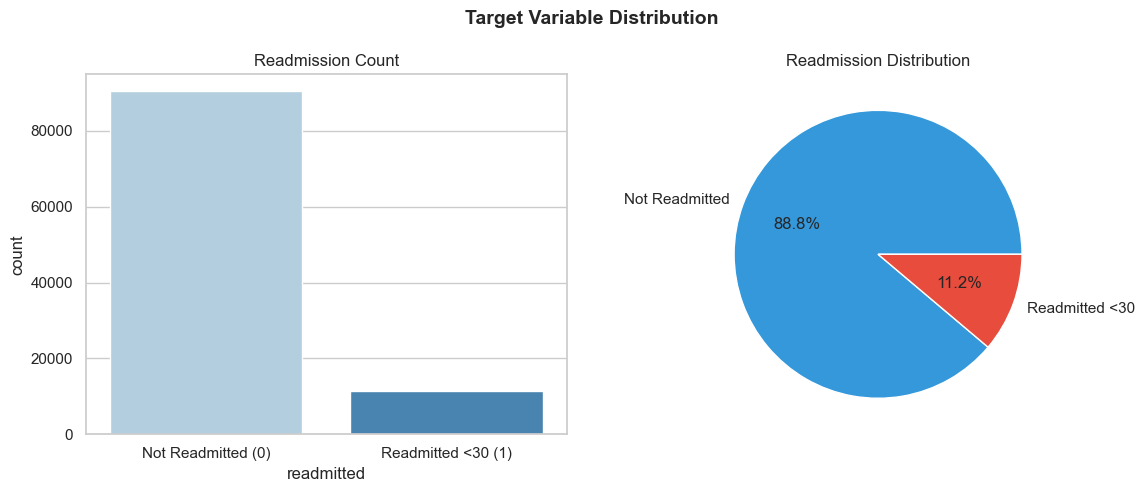

In [10]:
# Visualize class imbalance

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(x='readmitted', data=df, ax=axes[0], palette='Blues')
axes[0].set_title('Readmission Count')
axes[0].set_xticklabels(['Not Readmitted (0)', 'Readmitted <30 (1)'])

# Pie chart
axes[1].pie(
    df['readmitted'].value_counts(),
    labels=['Not Readmitted', 'Readmitted <30'],
    autopct='%1.1f%%',
    colors=['#3498db', '#e74c3c']
)
axes[1].set_title('Readmission Distribution')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/01_target_distribution.png', dpi=150, bbox_inches='tight')

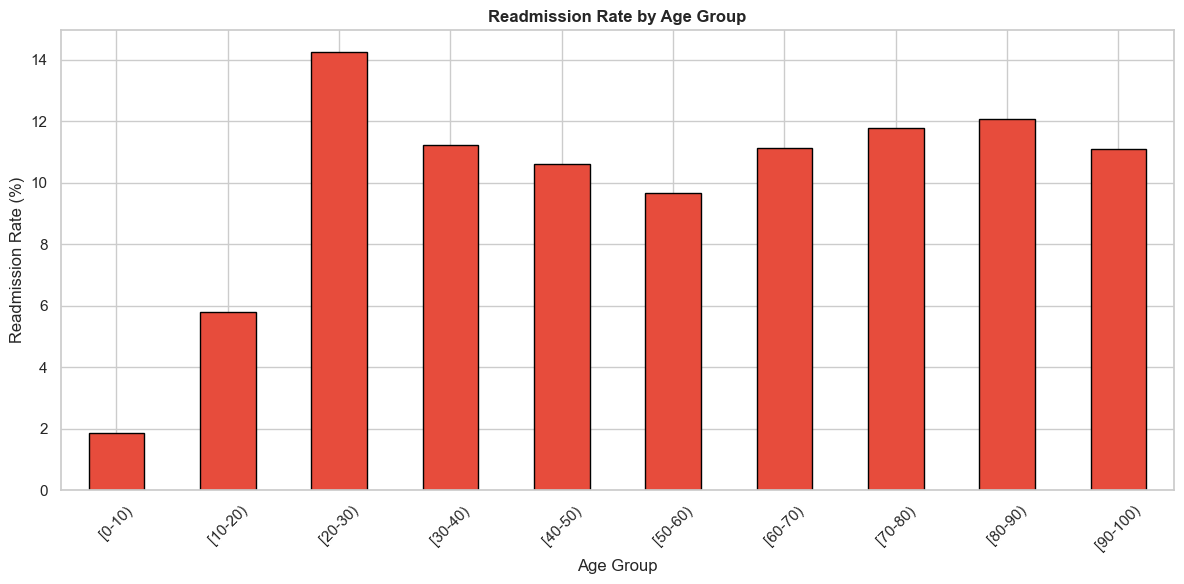

In [11]:
# Age vs Readmission

plt.figure(figsize=(12, 6))
readmission_by_age = df.groupby('age')['readmitted'].mean() * 100

readmission_by_age.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Readmission Rate by Age Group', fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/02_age_vs_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

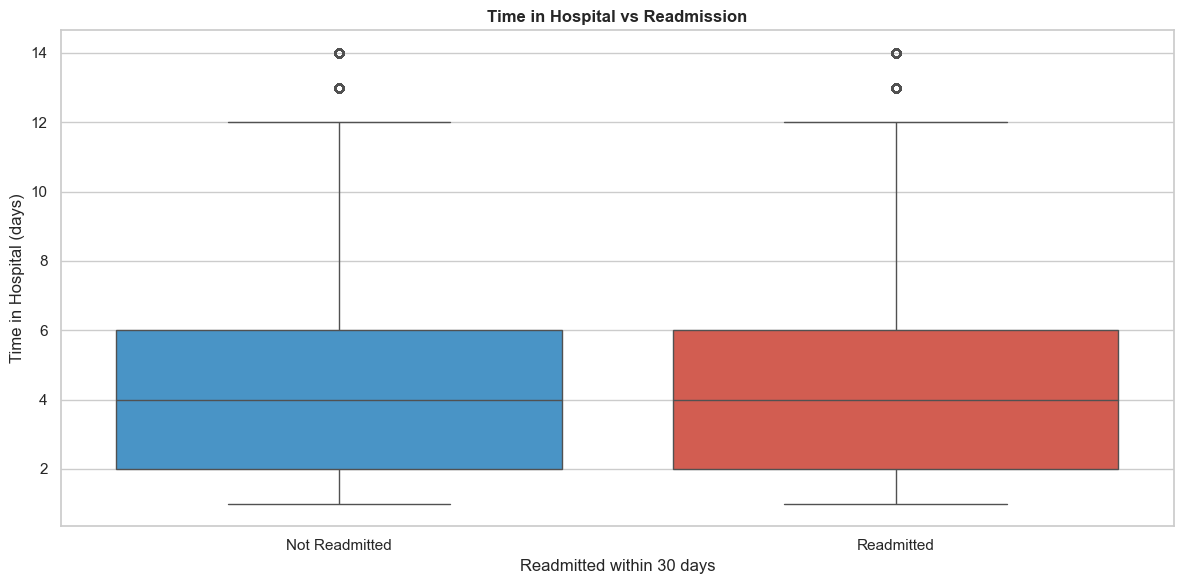

In [12]:
# Time in Hospital vs Readmission

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='readmitted',
    y='time_in_hospital',
    data=df,
    palette=['#3498db', '#e74c3c']
)
plt.title('Time in Hospital vs Readmission', fontweight='bold')
plt.xlabel('Readmitted within 30 days')
plt.ylabel('Time in Hospital (days)')
plt.xticks([0, 1], ['Not Readmitted', 'Readmitted'])
plt.tight_layout()
plt.savefig('../reports/03_time_in_hospital.png', dpi=150, bbox_inches='tight')
plt.show()

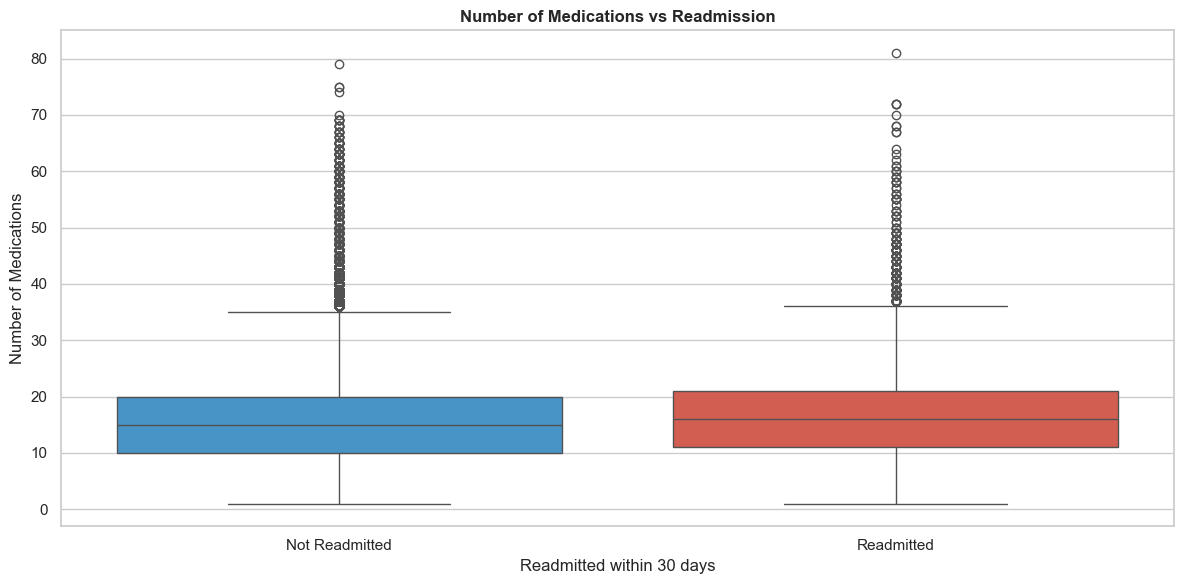

In [13]:
# Number of Medications vs Readmission

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='readmitted',
    y='num_medications',
    data=df,
    palette=['#3498db', '#e74c3c']
)
plt.title('Number of Medications vs Readmission', fontweight='bold')
plt.xlabel('Readmitted within 30 days')
plt.ylabel('Number of Medications')
plt.xticks([0, 1], ['Not Readmitted', 'Readmitted'])
plt.tight_layout()
plt.savefig('../reports/04_num_medications.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Age group sample size check
age_stats = df.groupby('age')['readmitted'].agg(['sum', 'count', 'mean'])
age_stats.columns = ['Readmitted', 'Total', 'Rate']
age_stats['Rate'] = age_stats['Rate'] * 100
print(age_stats)

          Readmitted  Total       Rate
age                                   
[0-10)             3    161   1.863354
[10-20)           40    691   5.788712
[20-30)          236   1657  14.242607
[30-40)          424   3775  11.231788
[40-50)         1027   9685  10.604027
[50-60)         1668  17256   9.666203
[60-70)         2502  22483  11.128408
[70-80)         3069  26068  11.773055
[80-90)         2078  17197  12.083503
[90-100)         310   2793  11.099177


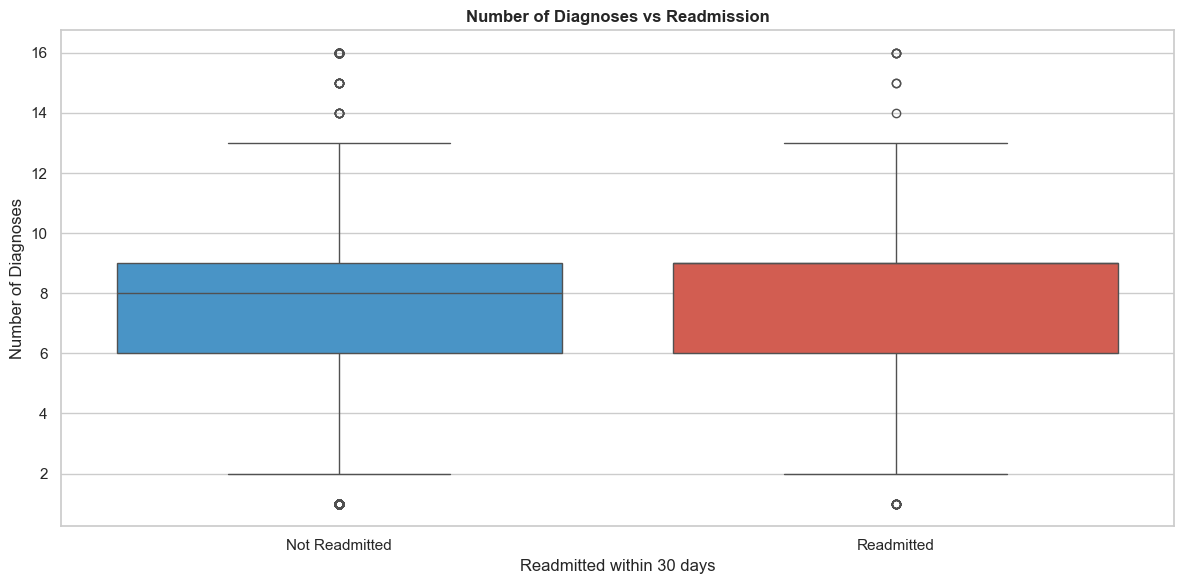

In [16]:
# Number of diagnoses vs readmission

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='readmitted',
    y='number_diagnoses',
    data=df,
    palette=['#3498db', '#e74c3c']
)
plt.title('Number of Diagnoses vs Readmission', fontweight='bold')
plt.xlabel('Readmitted within 30 days')
plt.ylabel('Number of Diagnoses')
plt.xticks([0, 1], ['Not Readmitted', 'Readmitted'])
plt.tight_layout()
plt.savefig('../reports/05_number_diagnoses.png', dpi=150, bbox_inches='tight')

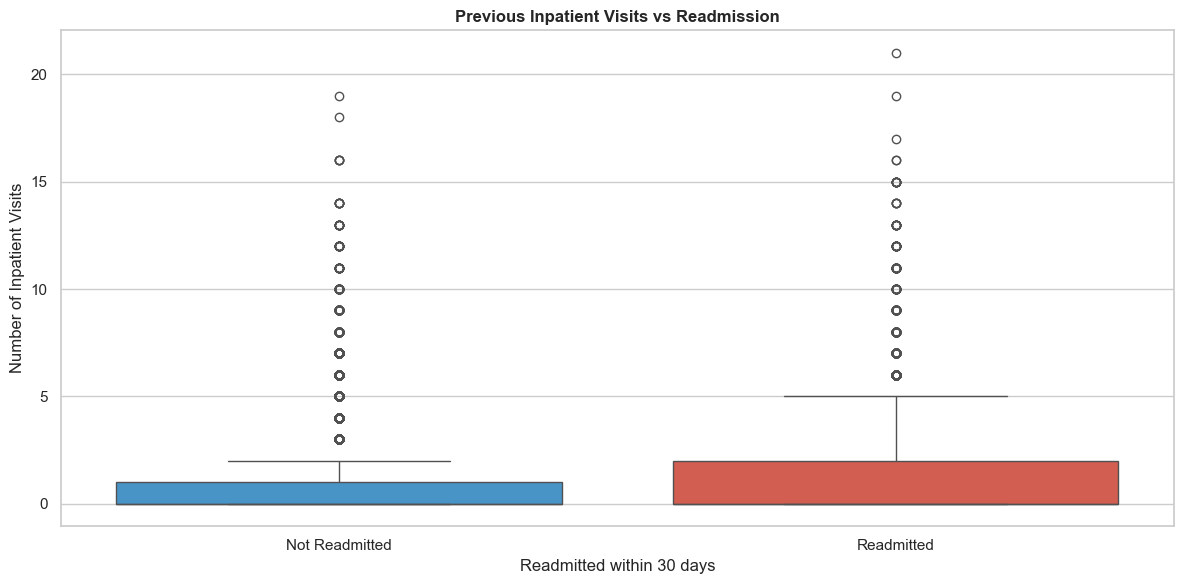

In [17]:
# Hospital visits history vs readmission

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='readmitted',
    y='number_inpatient',
    data=df,
    palette=['#3498db', '#e74c3c']
)
plt.title('Previous Inpatient Visits vs Readmission', fontweight='bold')
plt.xlabel('Readmitted within 30 days')
plt.ylabel('Number of Inpatient Visits')
plt.xticks([0, 1], ['Not Readmitted', 'Readmitted'])
plt.tight_layout()
plt.savefig('../reports/06_inpatient_visits.png', dpi=150, bbox_inches='tight')

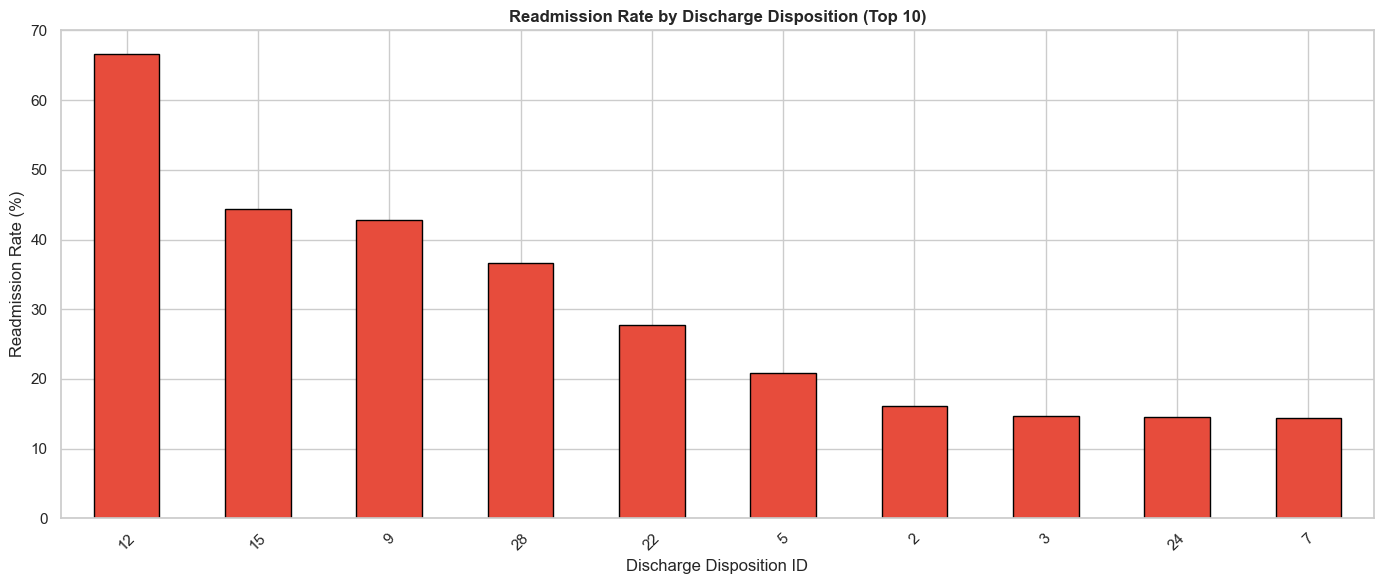

In [18]:
# Discharge disposition vs readmission

plt.figure(figsize=(14, 6))
discharge_rate = df.groupby('discharge_disposition_id')['readmitted'].mean() * 100
discharge_rate.sort_values(ascending=False).head(10).plot(
    kind='bar',
    color='#e74c3c',
    edgecolor='black'
)
plt.title('Readmission Rate by Discharge Disposition (Top 10)', fontweight='bold')
plt.xlabel('Discharge Disposition ID')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/07_discharge_disposition.png', dpi=150, bbox_inches='tight')

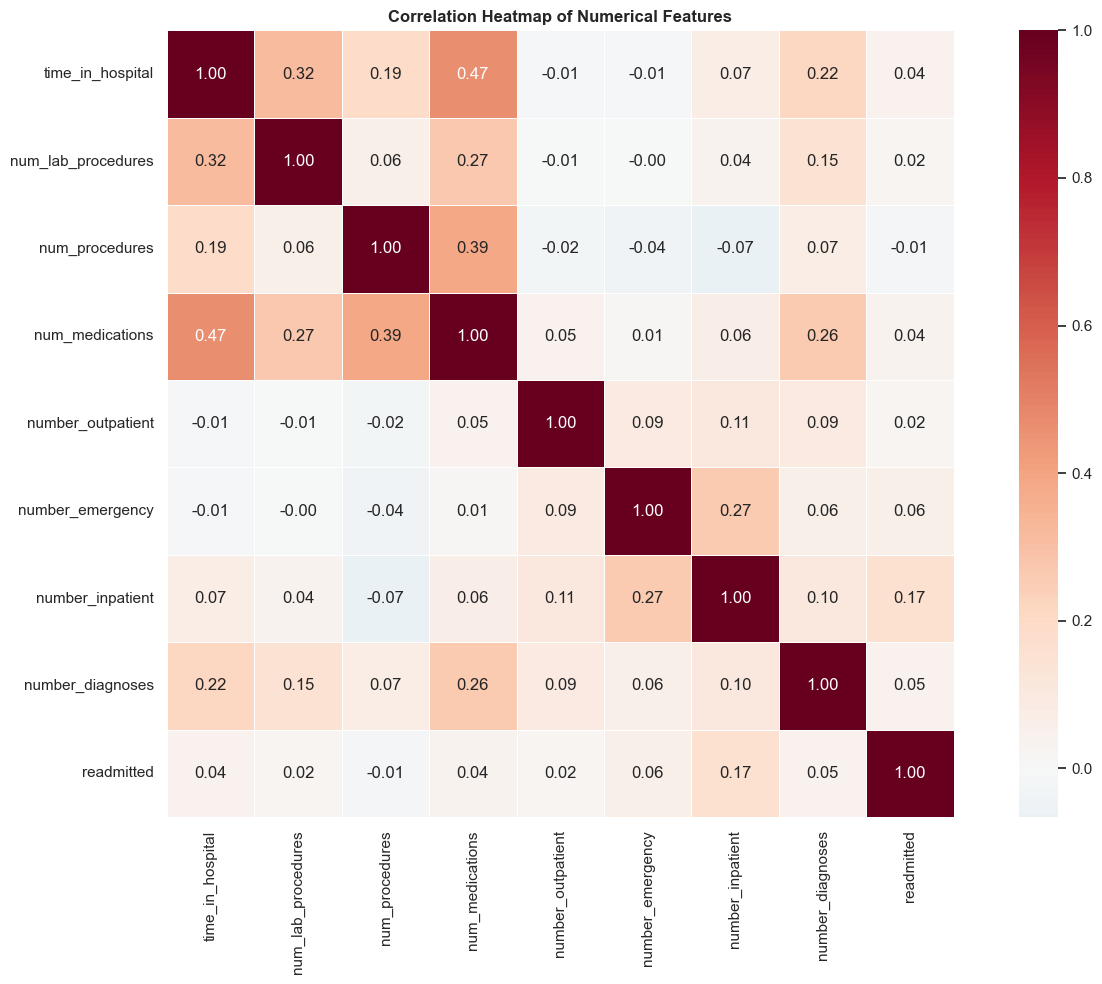

In [20]:
# Correlation heatmap of numerical features

plt.figure(figsize=(14, 10))

numerical_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'readmitted'
]

corr_matrix = df[numerical_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Heatmap of Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/08_correlation_heatmap.png', dpi=150, bbox_inches='tight')

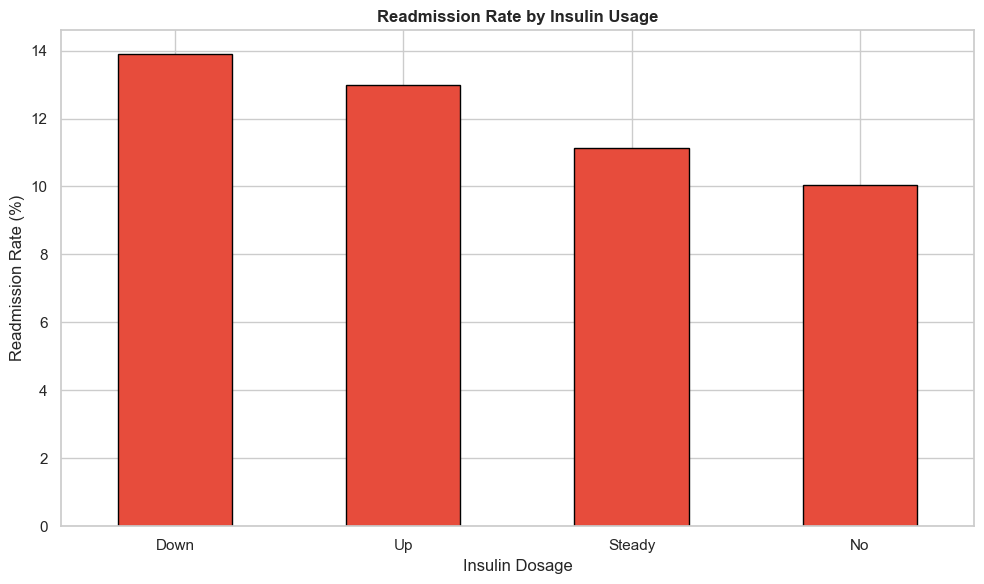

In [21]:
# Insulin usage vs readmission

plt.figure(figsize=(10, 6))
insulin_rate = df.groupby('insulin')['readmitted'].mean() * 100
insulin_rate.sort_values(ascending=False).plot(
    kind='bar',
    color='#e74c3c',
    edgecolor='black'
)
plt.title('Readmission Rate by Insulin Usage', fontweight='bold')
plt.xlabel('Insulin Dosage')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/09_insulin_vs_readmission.png', dpi=150, bbox_inches='tight')

In [22]:
# EDA summary

eda_summary = """
EDA KEY FINDINGS
=================
1. CLASS IMBALANCE
   - 88.8% not readmitted vs 11.2% readmitted
   - Requires SMOTE during preprocessing

2. STRONGEST PREDICTOR
   - number_inpatient (0.17 correlation)
   - Prior hospitalizations = chronic/complex patients

3. AGE INSIGHT
   - [80-90) age group: 12.1% rate with 17,197 patients
   - Elderly patients are highest reliable risk group

4. INSULIN INSIGHT
   - Adjusted insulin (Up/Down) = 13-14% readmission rate
   - vs No insulin = 10.1% rate
   - Unstable diabetes = higher readmission risk

5. MULTICOLLINEARITY
   - time_in_hospital & num_medications (0.47)
   - time_in_hospital & num_lab_procedures (0.32)
   - num_medications & num_procedures (0.39)

6. FEATURE ENGINEERING PLANNED
   - service_utilization score
   - medication_procedure complexity score
"""
print(eda_summary)

# Save to reports
with open('../reports/eda_summary.txt', 'w') as f:
    f.write(eda_summary)
print("EDA summary saved!")


EDA KEY FINDINGS
1. CLASS IMBALANCE
   - 88.8% not readmitted vs 11.2% readmitted
   - Requires SMOTE during preprocessing

2. STRONGEST PREDICTOR
   - number_inpatient (0.17 correlation)
   - Prior hospitalizations = chronic/complex patients

3. AGE INSIGHT
   - [80-90) age group: 12.1% rate with 17,197 patients
   - Elderly patients are highest reliable risk group

4. INSULIN INSIGHT
   - Adjusted insulin (Up/Down) = 13-14% readmission rate
   - vs No insulin = 10.1% rate
   - Unstable diabetes = higher readmission risk

5. MULTICOLLINEARITY
   - time_in_hospital & num_medications (0.47)
   - time_in_hospital & num_lab_procedures (0.32)
   - num_medications & num_procedures (0.39)

6. FEATURE ENGINEERING PLANNED
   - service_utilization score
   - medication_procedure complexity score

EDA summary saved!
